# K Nearest Neighbors Regression

KNN regression makes a prediction for a new instance by taking the average target value for the k closest points.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from warnings import filterwarnings

filterwarnings('ignore')

# Data Preparation

In [2]:
boston = fetch_california_housing()
boston.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [3]:
print(boston['DESCR'][:1265])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [4]:
print(boston['data'].shape, boston['target'].shape)

X = boston['data']
y = boston['target']

(20640, 8) (20640,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print()
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (15480, 8)
X_test: (5160, 8)

y_train: (15480,)
y_test: (5160,)


# Distance metrics

Minkowski distance is a metric that measures the distance between two n-dimensional points.

For $\vec{x} = \begin{pmatrix} x_1 \\ x_2 \\ \vdots \\ x_n\end{pmatrix} $ and $\vec{y} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_n\end{pmatrix}$ the Minkowski distance of order $p \ge 1$  for $\vec{x}$ and $\vec{y}$ is given by:

$$
D(\vec{x}, \vec{y}) = \bigg(\sum_{i=1}^n|x_i - y_i|^p\bigg)^{1/p}
$$

Minkowski distance is a generalization of Manhattan ($p=1$) and Euclidean ($p=2$) distances.

In [6]:
# Find the distance between the given instance
# and all points in the training set
instance = X_test[0]
target = y_test[0]

print('instance:')
for k, v in zip(boston['feature_names'], instance):
    print(f'\t{k:8}:{v:10}')
    
print('\ntarget (MEDV) :', target)

instance:
	MedInc  :    1.6812
	HouseAge:      25.0
	AveRooms:4.192200557103064
	AveBedrms:1.0222841225626742
	Population:    1392.0
	AveOccup:3.8774373259052926
	Latitude:     36.06
	Longitude:   -119.01

target (MEDV) : 0.477


In [7]:
# minkowski distances for p = 1, 2, 3
dist1 = (np.abs(X_train - instance) ** 1).sum(axis=1) ** (1/1)
dist2 = (np.abs(X_train - instance) ** 2).sum(axis=1) ** (1/2)
dist3 = (np.abs(X_train - instance) ** 3).sum(axis=1) ** (1/3)

print('p = 1:', dist1[:5])
print()
print('p = 2:', dist2[:5])
print()
print('p = 3:', dist3[:5])

p = 1: [552.16591501 463.44629134 703.90481491 250.63387579 701.9227562 ]

p = 2: [532.1496895  435.36692504 681.11132505 233.17333144 686.05810155]

p = 3: [532.00207298 435.00881336 681.00101861 233.00284412 686.00038715]


# The Closest K points

In [8]:
k = 5

dist1_sorted_indx = dist1.argsort()
dist2_sorted_indx = dist2.argsort()
dist3_sorted_indx = dist3.argsort()

closest_k1 = dist1_sorted_indx[:k]
closest_k2 = dist2_sorted_indx[:k]
closest_k3 = dist3_sorted_indx[:k]

In [9]:
dist1[dist1_sorted_indx[:5]]

array([ 7.18817655,  8.91730269,  9.14732361,  9.49614624, 10.47110294])

In [10]:
print('The indices of the closest', k, 'points.\n')
print('p = 1:', closest_k1)
print('p = 2:', closest_k2)
print('p = 3:', closest_k3)

The indices of the closest 5 points.

p = 1: [11033 14964  2124 14784 14688]
p = 2: [11033 14964  2124 14688  6903]
p = 3: [ 2124 14964 11033  6903 14688]


In [11]:
print('The targets of the closest', k, 'points.\n')
print('p = 1:', y_train[closest_k1])
print('p = 2:', y_train[closest_k2])
print('p = 3:', y_train[closest_k3])

The targets of the closest 5 points.

p = 1: [0.72  3.25  1.422 0.529 1.375]
p = 2: [0.72  3.25  1.422 1.375 1.348]
p = 3: [1.422 3.25  0.72  1.348 1.375]


# Making predictions

The prediction is just average of the closest points targets.

2.063185914728682
1.150312177155887

2.0703489205426355
1.155125478598883


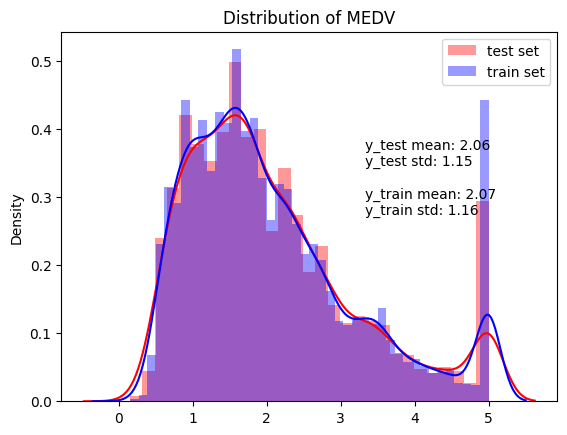

In [12]:
print(y_test.mean())
print(y_test.std())
print()
print(y_train.mean())
print(y_train.std())

description = f'''y_test mean: {y_test.mean():.2f}
y_test std: {y_test.std():.2f}

y_train mean: {y_train.mean():.2f}
y_train std: {y_train.std():.2f}'''

fig = plt.figure()
fig.text(0.6, .50, description)

sns.distplot(y_test, color='red', label='test set')
sns.distplot(y_train, color='blue', label='train set')
plt.title('Distribution of MEDV')
plt.legend();

In [13]:
pred1 = y_train[closest_k1].mean()
pred2 = y_train[closest_k2].mean()
pred3 = y_train[closest_k3].mean()


print(
f'''
Prediction:

    p = 1: {pred1}
    p = 2: {pred2}
    p = 3: {pred3}
''')



Prediction:

    p = 1: 1.4591999999999998
    p = 2: 1.623
    p = 3: 1.6229999999999998



# Batch predictions

In [14]:
p = 2

# Every train instance - every test instance
dist2 = (np.abs(X_train - X_test[:,np.newaxis,:]) ** p).sum(axis=2)
# each row is an instance from X_test 
# each column is the distance from the instance 
# in X_test to each instance from X_train
dist2.shape

(5160, 15480)

In [15]:
# sort each row
dist2_indx = dist2.argsort()
dist2_indx

array([[11033, 14964,  2124, ...,   190,  2167, 13795],
       [12736,  5498,  7575, ...,   190,  2167, 13795],
       [ 3891, 12570, 13031, ...,   190,  2167, 13795],
       ...,
       [ 2248,  8133, 13648, ...,   190,  2167, 13795],
       [14637, 12659,  1402, ...,   190,  2167, 13795],
       [10320,  4742,  1883, ...,   190,  2167, 13795]],
      shape=(5160, 15480))

In [16]:
# the classes of the closest 5 points
closest5 = y_train[dist2_indx][:,:5]
closest5

array([[0.72 , 3.25 , 1.422, 1.375, 1.348],
       [1.772, 1.22 , 0.765, 0.48 , 1.174],
       [3.417, 3.229, 1.821, 2.226, 3.769],
       ...,
       [1.969, 1.774, 1.547, 2.267, 0.956],
       [1.582, 1.432, 0.707, 2.875, 2.915],
       [1.905, 4.421, 3.964, 1.884, 1.732]], shape=(5160, 5))

In [17]:
predictions = closest5.mean(axis=1)

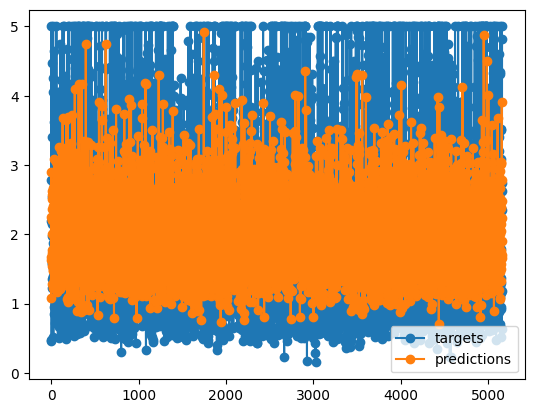

In [18]:
plt.plot(y_test, '-o', label='targets')
plt.plot(predictions, '-o', label='predictions')
plt.legend();

In [19]:
mse = ((predictions - y_test) ** 2).mean()
print(mse)

mae = np.abs(predictions - y_test).mean()
print(mae)

1.132222068863644
0.8188566406976745


In [20]:
from knn import KNNRegressor

In [21]:
knn = KNNRegressor(n_neighbors=4)

knn.fit(X_train, y_train)

preds = knn.predict(X_test)

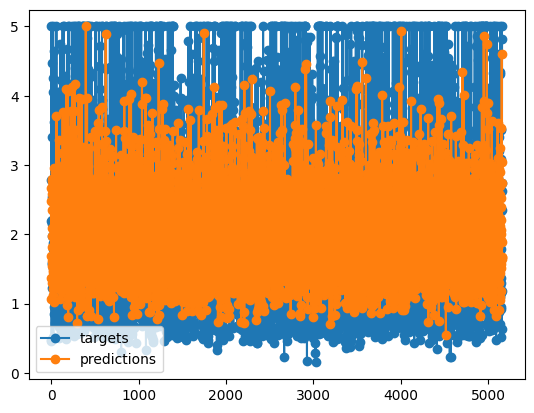

In [22]:
plt.plot(y_test, '-o', label='targets')
plt.plot(preds, '-o', label='predictions')
plt.legend();

In [23]:
mse = ((preds - y_test) ** 2).mean()
print(mse)

mae = np.abs(preds - y_test).mean()
print(mae)

1.154237702968997
0.8244962839147286
